# 09. 応用 — 信号・画像・金融・機械学習

**学習目標**: これまでの道具を実データ風の題材で使う。音(スペクトログラム)、画像
(2D FFT・圧縮)、金融時系列(探索的周波数解析と **その限界**)、そして ML への接続。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## 1. 音声信号 — スペクトログラム(07 章の再訪)

チャープ音の時間周波数表示。音の解析の基本図です。

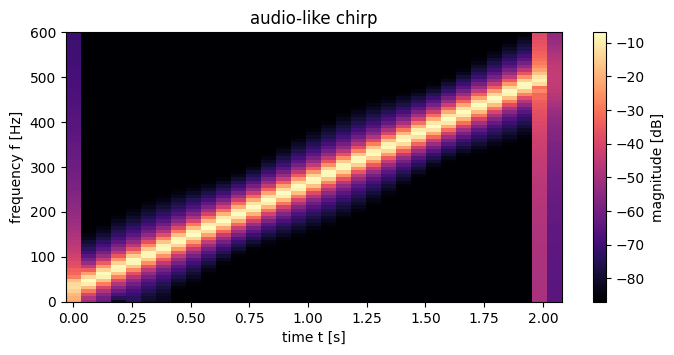

In [2]:
fs = 2000.0
t, x = datasets.make_chirp(fs=fs, duration=2.0, f0=30.0, f1=500.0)
f, tt, S = transforms.spectrogram_db(x, fs, nperseg=256)
plotting.plot_spectrogram(f, tt, S, fmax=600, title="audio-like chirp")
plt.show()

## 2. 画像の 2D FFT

画像は 2 次元信号。2D FFT は「どの向き・どの細かさの縞模様」が含まれるかを示します。
中心が低周波(全体の明暗・なだらかな変化)、外側が高周波(エッジ・細部)です。

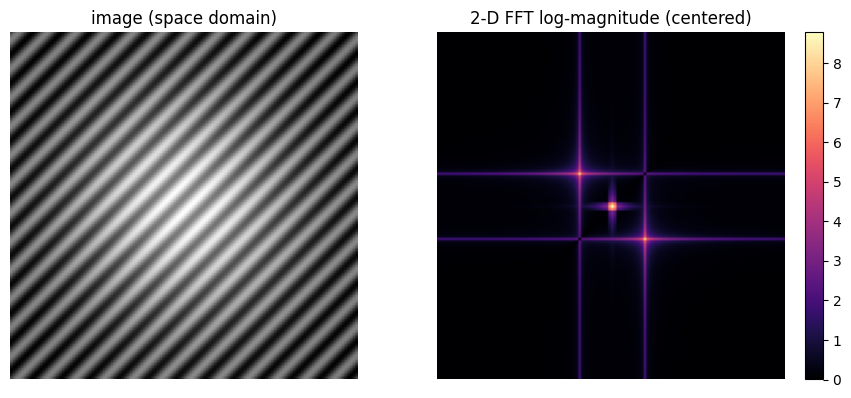

In [3]:
img = datasets.make_test_image(128)
plotting.plot_image_and_spectrum(img)
plt.show()

### 低周波だけで再構成(ぼかし)と係数間引き圧縮

中心の低周波だけ残すと **ぼけた**(なめらかな)画像になります。
大きい係数だけ残す(間引く)と、少ないデータで元画像を近似できます = 変換符号化(JPEG の精神)。

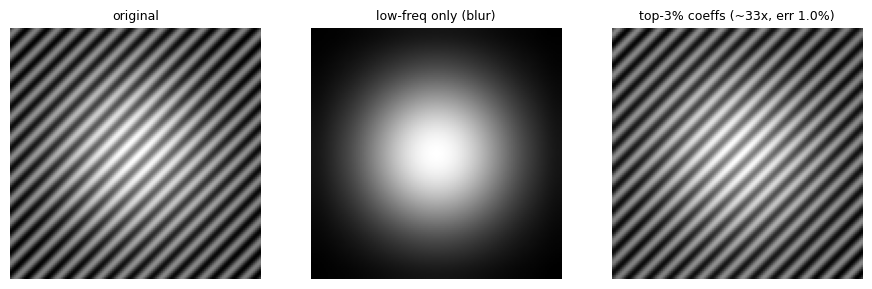

In [4]:
# Keep only low frequencies (blur) vs keep only the largest coefficients (compress).
F = np.fft.fftshift(np.fft.fft2(img))

def keep_central(spec, frac):
    n = spec.shape[0]
    r = max(1, int(n * frac / 2))
    c = n // 2
    mask = np.zeros_like(spec, dtype=bool)
    mask[c - r:c + r, c - r:c + r] = True
    return spec * mask

low = np.fft.ifft2(np.fft.ifftshift(keep_central(F, 0.12))).real

mag = np.abs(F)
keep = int(0.03 * mag.size)                          # keep top 3% of coefficients
thr = np.partition(mag.ravel(), -keep)[-keep]
Fc = np.where(mag >= thr, F, 0)
comp = np.fft.ifft2(np.fft.ifftshift(Fc)).real
ratio = mag.size / np.count_nonzero(Fc)
rel_err = np.linalg.norm(img - comp) / np.linalg.norm(img)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, im, title in zip(ax, [img, low, comp],
                        ["original", "low-freq only (blur)",
                         f"top-3% coeffs (~{ratio:.0f}x, err {rel_err:.1%})"]):
    a.imshow(im, cmap="gray"); a.set_title(title, fontsize=9); a.axis("off")
plt.show()

### ハイパス=エッジ、方向フィルタ

高周波だけ残すと **エッジ** が出る。周波数面の中央の行(または列)だけ残すと、
特定方向のなめらかな構造だけが残る(方向選択フィルタ)。

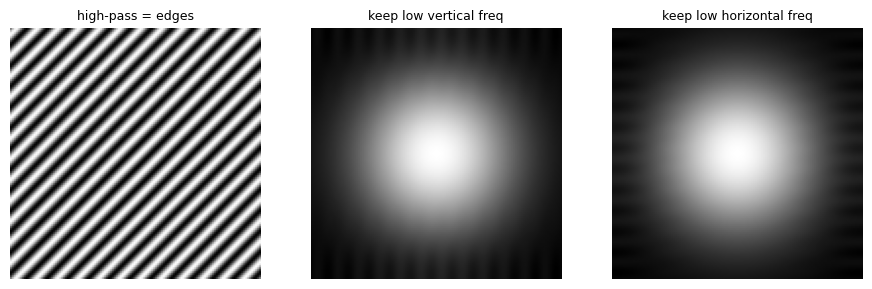

In [5]:
# High-pass = edges; keeping a center row/column band keeps one spatial direction.
F2 = np.fft.fftshift(np.fft.fft2(img))
nimg = F2.shape[0]
cc = nimg // 2
block = np.zeros_like(F2, dtype=bool)
block[cc - 8:cc + 8, cc - 8:cc + 8] = True
high = np.fft.ifft2(np.fft.ifftshift(F2 * ~block)).real      # drop low freqs -> edges
row = np.zeros_like(F2, dtype=bool); row[cc - 3:cc + 3, :] = True
col = np.zeros_like(F2, dtype=bool); col[:, cc - 3:cc + 3] = True
horiz = np.fft.ifft2(np.fft.ifftshift(F2 * row)).real        # keep low vertical freq
vert = np.fft.ifft2(np.fft.ifftshift(F2 * col)).real         # keep low horizontal freq
fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
for a, im_, ttl in zip(ax, [high, horiz, vert],
                       ["high-pass = edges", "keep low vertical freq", "keep low horizontal freq"],
                       strict=True):
    a.imshow(im_, cmap="gray"); a.set_title(ttl, fontsize=9); a.axis("off")
plt.show()

## 3. 金融時系列 — 探索的周波数解析とその限界

合成した日次価格の対数リターンを FFT します。ただし金融では結果の解釈に強い注意が要ります。

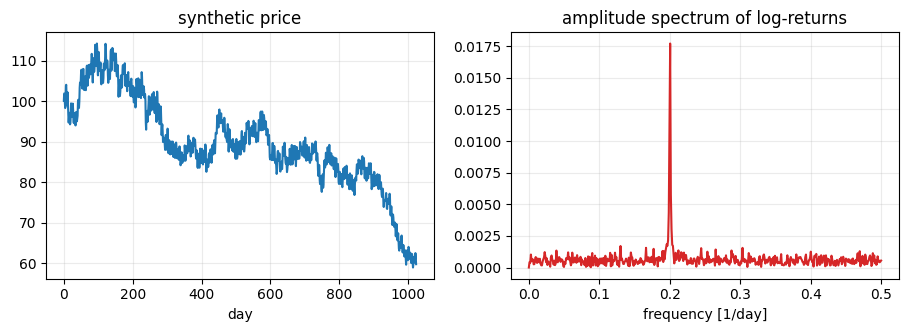

In [6]:
price = datasets.load_price_series(n=1024, seed=0)   # synthetic: random walk + faint 5-day cycle
ret = np.diff(np.log(price))
freqs, amp = transforms.amplitude_spectrum(ret - ret.mean(), fs=1.0)  # fs = 1 / day

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(price, color="#1f77b4"); ax[0].set_title("synthetic price"); ax[0].set_xlabel("day")
ax[0].grid(alpha=.25)
ax[1].plot(freqs, amp, color="#d62728"); ax[1].set_title("amplitude spectrum of log-returns")
ax[1].set_xlabel("frequency [1/day]"); ax[1].grid(alpha=.25)
plt.show()

```{admonition} 金融時系列でフーリエ解析を使うときの注意(必読)
:class: warning
- **非定常**: 株価・リターンは時間とともに統計的性質が変わりやすい。FFT は「定常で周期的」を
  暗に仮定するので、スペクトルの山を素朴に「周期」と読んではいけない。
- **見かけの周期性**: 有限データではランダムノイズでもスペクトルに山が立つ(偶然のピーク)。
  有意性は帰無分布やサロゲートデータと比較して評価すべき。
- **予測力の保証なし**: FFT は **探索的分析** には有用だが、過去のスペクトルが将来の値動きを
  予測する保証はない。
- **将来情報の混入(look-ahead)**: 周波数フィルタ(とくに位相ゼロ/両側フィルタ)は
  未来の値を使うため、バックテストに使うと **リーク** する。因果的(片側)フィルタを使うこと。
```

## 4. 機械学習への接続(概念)

- **Fourier features**: 入力 $x$ を $[\cos(2\pi b x),\sin(2\pi b x)]$ に写すと、ニューラルネットが
  高周波関数を学習しやすくなる(座標 MLP・NeRF の鍵)。
- **スペクトル前処理**: 音声・振動の分類では、生波形より **スペクトログラム** を入力にすると強い。
- **Neural operators(FNO)**: 偏微分方程式の解作用素を **フーリエ空間** で学習する(08 章の延長)。
- 線形代数の PCA/SVD(`analytics/linear_algebra`)とも双子: どちらも「良い基底へ射影して
  少数成分で表す」発想。

## TODO(発展として追記予定)

```{admonition} TODO
:class: tip
- 実画像(`scikit-image` の `data.camera()` 等)での 2D FFT(`pip install -e ".[extras]"`)
- 音声 WAV の読み込みとメル尺度スペクトログラム
- Fourier features を使った小さな回帰デモ(高周波関数の学習)
- 金融: ウェルチ法(平均ピリオドグラム)とサロゲート検定で偶然のピークを棄却
```